# Hierarchical Clustering
Hierarchical clustering is a type of unsupervised machine learning algorithm used for grouping similar data points into clusters based on a measure of similarity (or distance). 

Unlike other clustering techniques like K-Means, it doesn’t require specifying the number of clusters in advance.



## Types of Hierarchical Clustering

There are two main types:

### 1. Agglomerative (Bottom-Up)

Starts with each data point as its own cluster.

Iteratively merges the closest pairs of clusters.

Continues until all points are in one cluster or a stopping condition is met.

### 2. Divisive (Top-Down)

Starts with all data points in one cluster.

Recursively splits the clusters until each point is in its own cluster or a criterion is met.

Less commonly used due to higher computational cost.

## Key Components
### Distance Metrics:
Determines how distances between points or clusters are calculated:

Euclidean (most common)

Manhattan

Cosine

Others depending on data nature

### Linkage Criteria:
Determines the distance between sets of observations:

Single linkage (min distance)

Complete linkage (max distance)

Average linkage (mean distance)

Ward’s linkage (minimizes variance within clusters)

## Dendrogram
A dendrogram is a tree-like diagram that shows the merging (or splitting) of clusters. You can "cut" the dendrogram at a chosen height to decide the number of clusters.





# 1. Agglomerative (Bottom-Up)


In [3]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np


X = np.array([[1, 2], [1, 4], [1, 0],
              [4, 2], [4, 4], [4, 0]])
clustering = AgglomerativeClustering(n_clusters=2).fit(X)

print(clustering.labels_)

[1 1 1 0 0 0]


Dataset – Credit Card Dataset. 

Assumption: The clustering technique assumes that each data point is similar enough to the other data points that the data at the starting can be assumed to be clustered in 1 cluster.

In [1]:
#  Importing the required libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings

warnings.simplefilter('ignore')

In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)

# View first few rows
print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [3]:
# Standardize features (mean = 0, std = 1) for better clustering performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [26]:
# Compute the linkage matrix using Ward's method (minimizes variance)
linkage_matrix = linkage(X_scaled, method='ward')


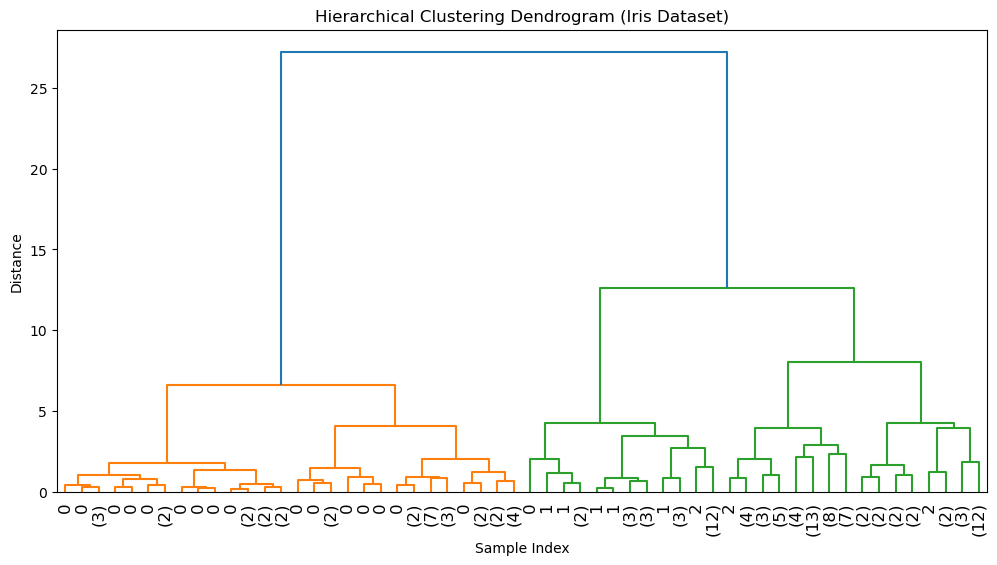

In [27]:
# Plot dendrogram to visualize cluster hierarchy
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix,
           truncate_mode='level',  # Show only the last p merged clusters
           p=5,
           labels=iris.target,
           leaf_rotation=90,
           leaf_font_size=12)
plt.title("Hierarchical Clustering Dendrogram (Iris Dataset)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()


In [4]:
# Perform Agglomerative Clustering (choose number of clusters)
n_clusters = 3
cluster = AgglomerativeClustering(n_clusters=n_clusters,linkage='ward')
labels = cluster.fit_predict(X_scaled)

# Add cluster labels to the DataFrame
df['cluster'] = labels


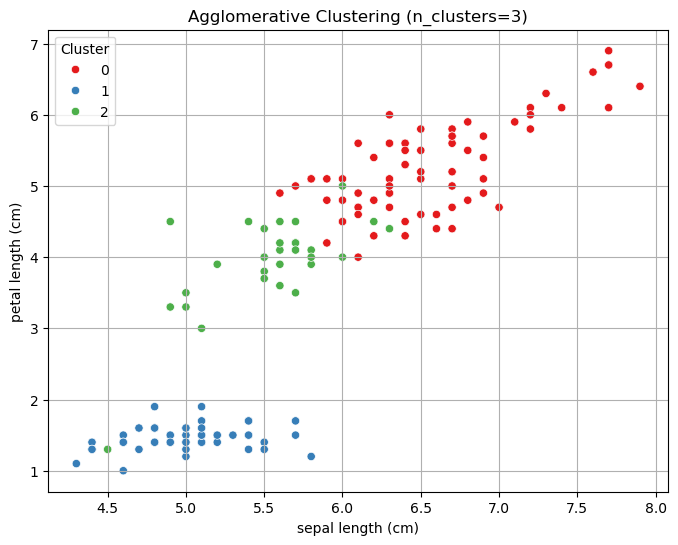

In [34]:
# Plot clusters using 2 features (for example: sepal length vs petal length)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x=feature_names[0], y=feature_names[2], hue='cluster', palette='Set1')
plt.title(f"Agglomerative Clustering (n_clusters={n_clusters})")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[2])
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


# Evaluate Silhouette Scores for Multiple Cluster Counts
The silhouette score ranges from -1 to 1:

+1 → Well matched to its own cluster, and poorly matched to others.

0 → On or near the decision boundary.

-1 → Possibly in the wrong cluster.

We’ll:

Compute silhouette scores for different values of n_clusters.

Plot silhouette scores to help determine the optimal number of clusters.

Visualize the best clustering again.

In [5]:
from sklearn.metrics import silhouette_score

In [12]:
# Try different numbers of clusters and compute silhouette scores
range_n_clusters = range(2,10)
silhouette_scores = []

for n in range(2, 10):
    clusterer = AgglomerativeClustering(n_clusters=n, metric='euclidean', linkage='ward')
    cluster_labels = clusterer.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"Silhouette Score for {n} clusters: {score:.4f}")


Silhouette Score for 2 clusters: 0.5770
Silhouette Score for 3 clusters: 0.4467
Silhouette Score for 4 clusters: 0.4006
Silhouette Score for 5 clusters: 0.3306
Silhouette Score for 6 clusters: 0.3149
Silhouette Score for 7 clusters: 0.3170
Silhouette Score for 8 clusters: 0.3109
Silhouette Score for 9 clusters: 0.3114


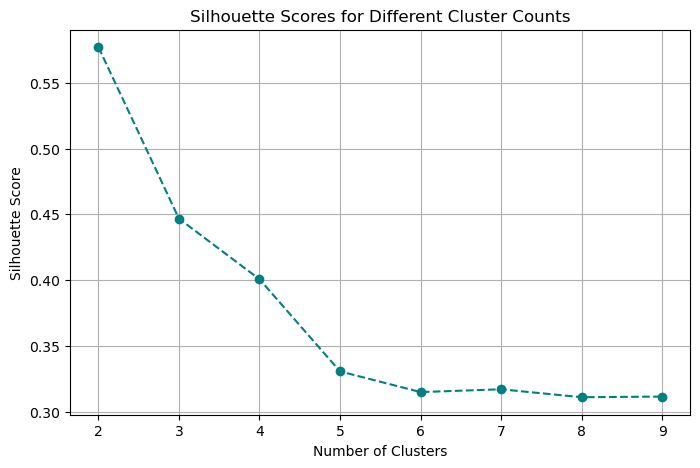

In [15]:
# Plotting silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(list(range(2, 10)), silhouette_scores, marker='o', linestyle='--', color='teal')
plt.title("Silhouette Scores for Different Cluster Counts")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 10))
plt.grid(True)
plt.show()


In [16]:
for n, score in zip(range(2, 10), silhouette_scores):
    print(f"{n} clusters → silhouette score: {score:.4f}")


2 clusters → silhouette score: 0.5770
3 clusters → silhouette score: 0.4467
4 clusters → silhouette score: 0.4006
5 clusters → silhouette score: 0.3306
6 clusters → silhouette score: 0.3149
7 clusters → silhouette score: 0.3170
8 clusters → silhouette score: 0.3109
9 clusters → silhouette score: 0.3114


# FULL SCRIPT

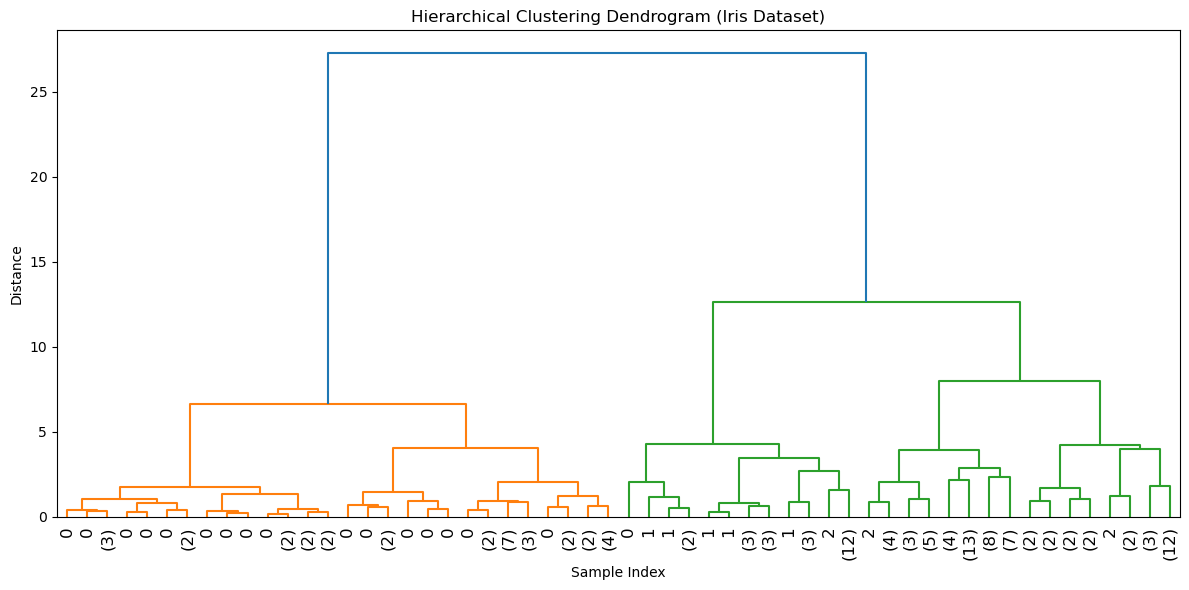

Silhouette Score for 2 clusters: 0.5770
Silhouette Score for 3 clusters: 0.4467
Silhouette Score for 4 clusters: 0.4006
Silhouette Score for 5 clusters: 0.3306
Silhouette Score for 6 clusters: 0.3149
Silhouette Score for 7 clusters: 0.3170
Silhouette Score for 8 clusters: 0.3109
Silhouette Score for 9 clusters: 0.3114


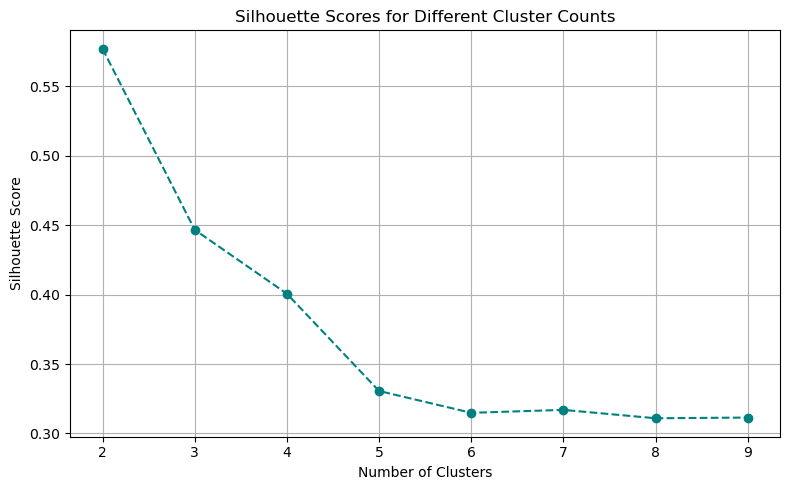


✅ Best number of clusters based on silhouette score: 3


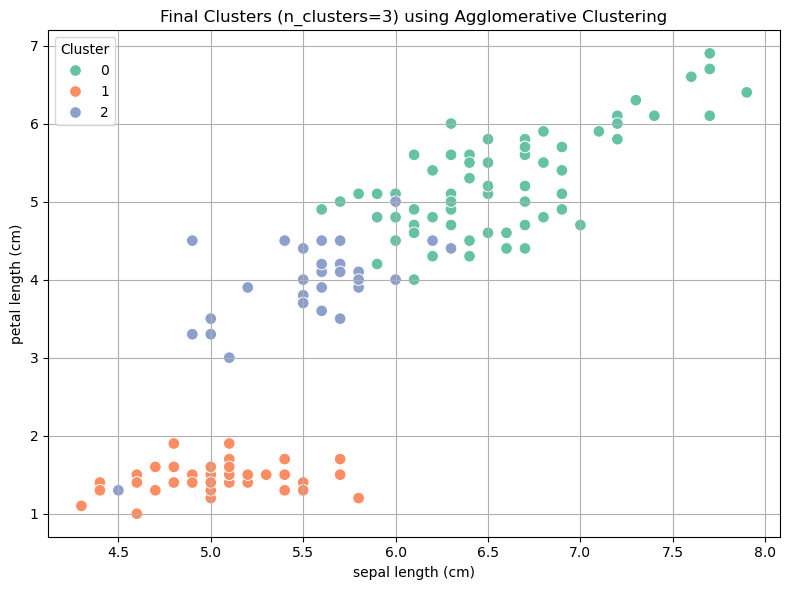

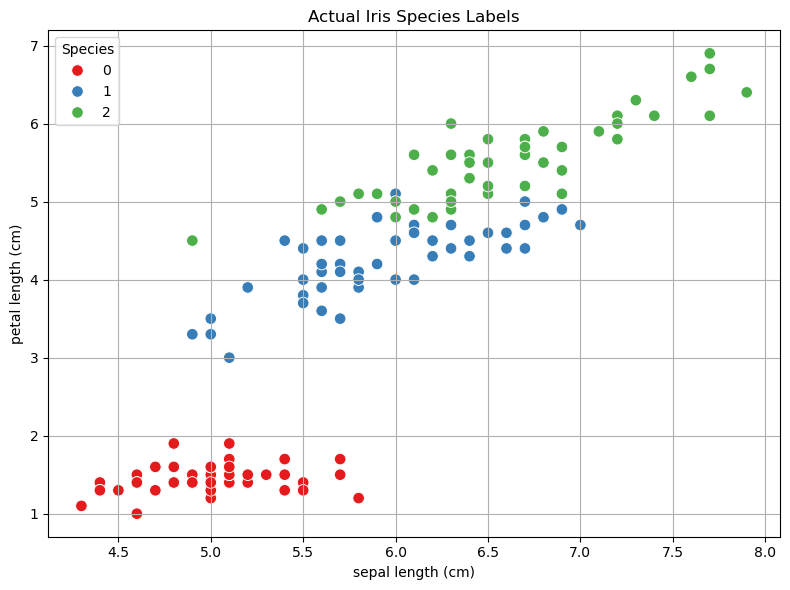

In [26]:
# ---------------------------
# 📦 Import Required Libraries
# ---------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# ---------------------------
# 📁 Create folder to save plots
# ---------------------------
output_folder = "clustering_plots"
os.makedirs(output_folder, exist_ok=True)

# ---------------------------
# 📥 Step 1: Load and Prepare the Dataset
# ---------------------------
iris = load_iris()
X = iris.data
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['true_species'] = iris.target  # ✅ Add true species labels

# ---------------------------
# ⚖️ Step 2: Standardize the Features
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# 🌳 Step 3: Compute Linkage Matrix for Dendrogram
# ---------------------------
linkage_matrix = linkage(X_scaled, method='ward')

# ---------------------------
# 📈 Step 4: Plot and Save the Dendrogram
# ---------------------------
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix,
           truncate_mode='level',
           p=5,
           labels=iris.target,
           leaf_rotation=90,
           leaf_font_size=12)
plt.title("Hierarchical Clustering Dendrogram (Iris Dataset)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig(f"{"C:\\Users\\franc\\Datascience_python\\plots"}\dendrogram.png")
plt.show()

# ---------------------------
# 🔁 Step 5: Silhouette Score Evaluation
# ---------------------------
silhouette_scores = []
cluster_range = list(range(2, 10))

for n in cluster_range:
    clusterer = AgglomerativeClustering(n_clusters=n, metric='euclidean', linkage='ward')
    labels = clusterer.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"Silhouette Score for {n} clusters: {score:.4f}")

# ---------------------------
# 📊 Step 6: Plot and Save Silhouette Scores
# ---------------------------
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, silhouette_scores, marker='o', linestyle='--', color='teal')
plt.title("Silhouette Scores for Different Cluster Counts")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(cluster_range)
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{"C:\\Users\\franc\\Datascience_python\\plots"}\silhouette_scores.png")
plt.show()

# ---------------------------
# ✅ Step 7: Final Clustering with Best Score
# ---------------------------
best_n = 3
print(f"\n✅ Best number of clusters based on silhouette score: {best_n}")

final_clusterer = AgglomerativeClustering(n_clusters=best_n, metric='euclidean', linkage='ward')
final_labels = final_clusterer.fit_predict(X_scaled)
df['final_cluster'] = final_labels

# ---------------------------
# 🎨 Step 8: Visualize Final Clusters
# ---------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df,
                x=feature_names[0],
                y=feature_names[2],
                hue='final_cluster',
                palette='Set2',
                s=70)
plt.title(f"Final Clusters (n_clusters=3) using Agglomerative Clustering")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[2])
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{"C:\\Users\\franc\\Datascience_python\\plots"}\clusters.png")
plt.show()

# ---------------------------
# 🎯 Step 9: Visualize True Species Labels for Comparison
# ---------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df,
                x=feature_names[0],
                y=feature_names[2],
                hue='true_species',
                palette='Set1',
                s=70)
plt.title("Actual Iris Species Labels")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[2])
plt.legend(title='Species')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{"C:\\Users\\franc\\Datascience_python\\plots"}\species_labels.png")
plt.show()


# Output Summary:
A dendrogram to visually inspect cluster merges

A line plot of silhouette scores to help pick the best cluster count

A final scatterplot colored by clusters

In [27]:
# Export Final DataFrame to CSV

output_csv = f"{"C:\\Users\\franc\\Datascience_python\\dataset"}\iris_with_clusters.csv"
df.to_csv(output_csv, index=False)
print(f"✅ Final DataFrame exported to: {output_csv}")

✅ Final DataFrame exported to: C:\Users\franc\Datascience_python\dataset\iris_with_clusters.csv
